<a href="https://colab.research.google.com/github/sharrenepf/Tugas-PCVK_Sharren/blob/main/Sharren_PCVK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


| Data | Keterangan |
|---|---|
| Nama | Sharren Elvaretta Pratamadya Fianto |
| NIM | 244107020191 |
| No. Absen | 24 |

---

In [88]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====

import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Sharren Elvaretta'
NIM = '244107020191'

N = int(NIM[-3:])

PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print(
    'TOKEN :',
    hashlib.sha256(kunci.encode()).hexdigest()[:16]
)

NAMA : Sharren Elvaretta
NIM : 244107020191 | N = 191
b      : 28
a      : 1.2
c      : 41
gamma  : 1.65
bit    : 7
WAKTU : 2026-09-19 14:03:30 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 1056c773648d441f


# PRAKTIKUM

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE = '/content/drive/MyDrive/PCVK IMAGES/' + NIM

print('Folder citra:', BASE)
print()

if os.path.exists(BASE):
    print('✓ Folder ditemukan.')
    print('\nIsi folder:')

    for file in os.listdir(BASE):
        print('-', file)

else:
    print('✗ Folder belum ditemukan.')

Folder citra: /content/drive/MyDrive/PCVK IMAGES/244107020191

✓ Folder ditemukan.

Isi folder:
- KTM1a.jpg
- KTM1b.jpg
- KTM1c.jpg
- KTM1d.jpg
- NIGHT1.jpg
- OBJ1.jpg


In [6]:
files = [
    'KTM1a.jpg',
    'KTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg',
    'OBJ1.jpg',
    'NIGHT1.jpg'
]

for filename in files:
    path = os.path.join(BASE, filename)

    if os.path.exists(path):
        img = cv.imread(path)

        if img is not None:
            print(f'✓ {filename:12s} berhasil dibaca - shape: {img.shape}')
        else:
            print(f'✗ {filename:12s} ditemukan tetapi gagal dibaca')
    else:
        print(f'✗ {filename:12s} tidak ditemukan')

✓ KTM1a.jpg    berhasil dibaca - shape: (1024, 1600, 3)
✓ KTM1b.jpg    berhasil dibaca - shape: (1014, 1600, 3)
✓ KTM1c.jpg    berhasil dibaca - shape: (998, 1600, 3)
✓ KTM1d.jpg    berhasil dibaca - shape: (1050, 1619, 3)
✓ OBJ1.jpg     berhasil dibaca - shape: (1280, 960, 3)
✓ NIGHT1.jpg   berhasil dibaca - shape: (1200, 1600, 3)


In [7]:
print('Transformasi Linier Brightness')
print('----------------------------------')

# Menggunakan parameter brightness dari NIM
brightness = PARAM['b']

print('Nilai brightness (b) =', brightness)

# Membaca citra KTM1a
original = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

# Pastikan gambar berhasil dibaca
if original is None:
    print('Error: KTM1a.jpg tidak berhasil dibaca')
else:
    # Transformasi brightness dengan saturasi 0-255
    brightness_image = np.clip(
        original.astype(np.int16) + brightness,
        0,
        255
    ).astype(np.uint8)

    print('Transformasi berhasil dilakukan.')
    print('Shape citra:', original.shape)

Transformasi Linier Brightness
----------------------------------
Nilai brightness (b) = 28
Transformasi berhasil dilakukan.
Shape citra: (1024, 1600, 3)


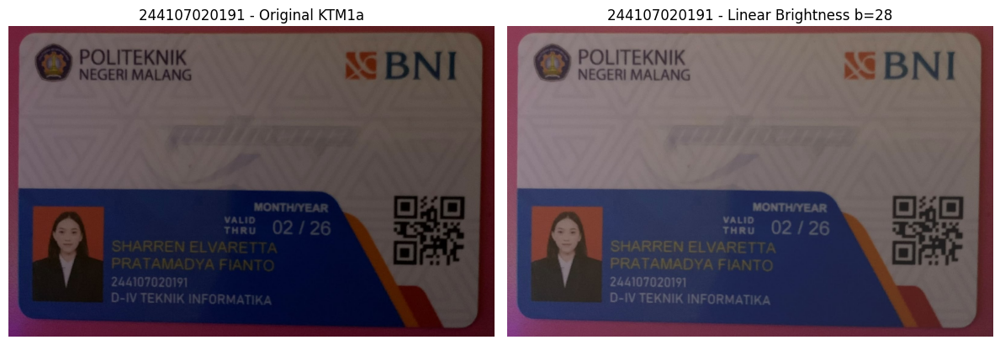

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Original KTM1a')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(brightness_image, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Linear Brightness b=' + str(PARAM['b']))
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
print('Mengubah tingkat kecerahan citra')
print('----------------------------------')

brightness = PARAM['b']

original = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

brightness_image = np.zeros(
    original.shape,
    original.dtype
)

# Transformasi linier brightness
for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        for k in range(original.shape[2]):
            brightness_image[i, j, k] = np.clip(
                int(original[i, j, k]) + brightness,
                0,
                255
            )

print('Brightness =', brightness)
print('Transformasi selesai.')

Mengubah tingkat kecerahan citra
----------------------------------
Brightness = 28
Transformasi selesai.


# Tugas Praktikum No. 1

In [10]:
def inverse_image(image):
    """
    Melakukan inverse citra:
    g(x,y) = 255 - f(x,y)
    """

    inverse = 255 - image

    return inverse.astype(np.uint8)

In [11]:
ktm1a = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

ktm1b = cv.imread(
    os.path.join(BASE, 'KTM1b.jpg')
)

print('KTM1a:', ktm1a.shape)
print('KTM1b:', ktm1b.shape)

KTM1a: (1024, 1600, 3)
KTM1b: (1014, 1600, 3)


In [12]:
inverse_ktm1a = inverse_image(ktm1a)
inverse_ktm1b = inverse_image(ktm1b)

print('Inverse KTM1a berhasil.')
print('Inverse KTM1b berhasil.')

Inverse KTM1a berhasil.
Inverse KTM1b berhasil.


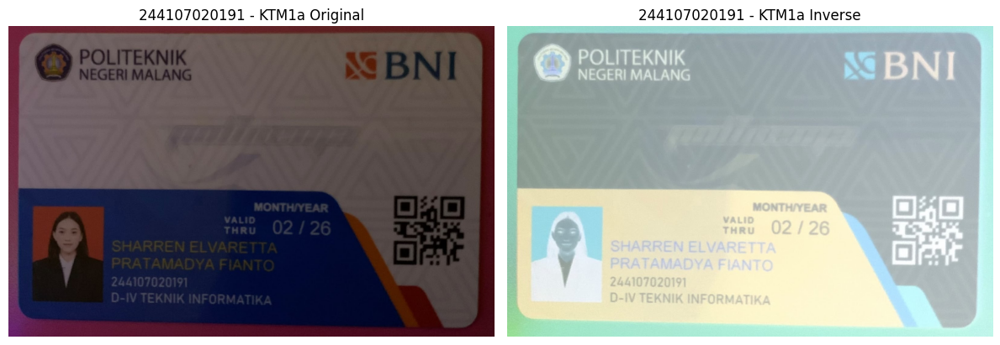

In [13]:
plt.figure(figsize=(12, 5))

# KTM1a original
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Original')
plt.axis('off')

# KTM1a inverse
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse_ktm1a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Inverse')
plt.axis('off')

plt.tight_layout()
plt.show()

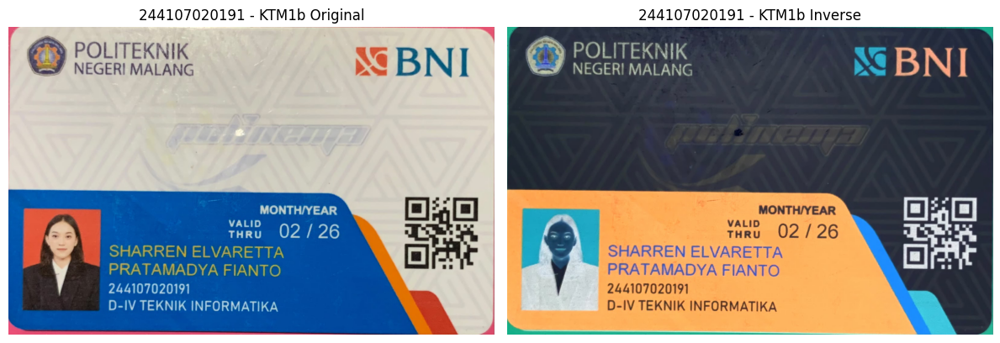

In [14]:
plt.figure(figsize=(12, 5))

# KTM1b original
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Original')
plt.axis('off')

# KTM1b inverse
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse_ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Inverse')
plt.axis('off')

plt.tight_layout()
plt.show()

## Perbandingan Untuk 4 Gambar

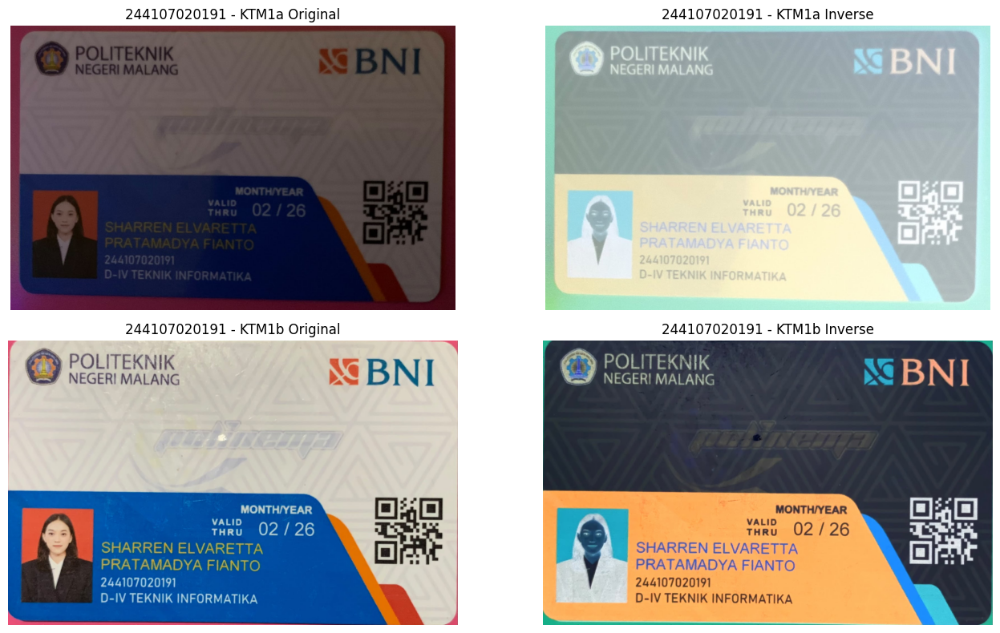

In [15]:
plt.figure(figsize=(14, 8))

# 1. KTM1a original
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Original')
plt.axis('off')

# 2. KTM1a inverse
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(inverse_ktm1a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Inverse')
plt.axis('off')

# 3. KTM1b original
plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Original')
plt.axis('off')

# 4. KTM1b inverse
plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(inverse_ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Inverse')
plt.axis('off')

plt.tight_layout()
plt.show()

## Penjelasan mengapa citra negatif dari KTM1a (ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap kontras.

* KTM1a kondisi pencahayaan yang gelap menyebabkan sebagian besar pixel memiliki intensitas rendah. Setelah dilakukan inverse dengan rumus \(g(x,y)=255-f(x,y)\), nilai intensitas rendah tersebut berubah menjadi intensitas tinggi sehingga citra negatif terlihat lebih terang, pucat, dan berkabut.

* KTM1b memiliki pencahayaan yang lebih baik
sehingga perbedaan intensitas antara bagian gelap dan terang lebih jelas. Setelah dilakukan inverse, perbedaan intensitas tersebut tetap dipertahankan sehingga citra negatif KTM1b masih terlihat lebih kontras.

# Tugas Praktikum No. 2

In [16]:
contrast = PARAM['a']

print('Transformasi Contrast')
print('---------------------')
print('Nilai contrast (a) =', contrast)

# Membaca KTM1a
original_contrast = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

# Konversi ke float agar perhitungan lebih aman
contrast_image = original_contrast.astype(np.float32)

# Transformasi contrast terhadap titik tengah 128
contrast_image = contrast * (
    contrast_image - 128
) + 128

# Batasi nilai pixel pada rentang 0-255
contrast_image = np.clip(
    contrast_image,
    0,
    255
).astype(np.uint8)

print('Transformasi contrast berhasil.')

Transformasi Contrast
---------------------
Nilai contrast (a) = 1.2
Transformasi contrast berhasil.


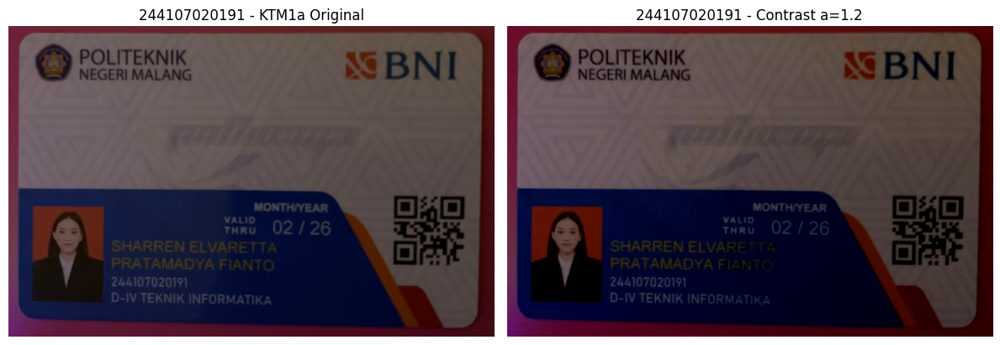

In [17]:
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original_contrast, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Original')
plt.axis('off')

# Contrast
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Contrast a=' + str(PARAM['a']))
plt.axis('off')

plt.tight_layout()
plt.show()

# Tugas Praktikum No. 3

In [21]:
# Tugas Praktikum 3
# Logarithmic Brightness

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

# Menggunakan nilai c dari parameter NIM
c = PARAM['c']

print('Nilai c =', c)

# Membaca citra KTM1a
original = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

# Mengubah tipe data agar perhitungan aman
original_float = original.astype(np.float32)

# Transformasi logarithmic
log_image = c * np.log1p(original_float)

# Normalisasi hasil agar berada pada rentang 0-255
log_image = cv.normalize(
    log_image,
    None,
    0,
    255,
    cv.NORM_MINMAX
)

# Konversi kembali ke uint8
log_image = log_image.astype(np.uint8)

print('Transformasi logarithmic selesai.')

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Nilai c = 41
Transformasi logarithmic selesai.


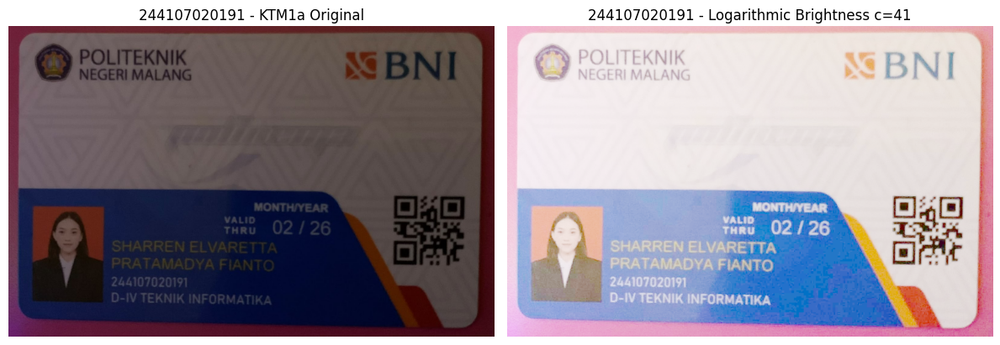

In [22]:
plt.figure(figsize=(12, 5))

# Citra asli
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Original')
plt.axis('off')

# Citra logarithmic
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(log_image, cv.COLOR_BGR2RGB))
plt.title(
    NIM + ' - Logarithmic Brightness c=' + str(PARAM['c'])
)
plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# Linear Brightness

b = PARAM['b']

linear_image = np.clip(
    original.astype(np.int16) + b,
    0,
    255
).astype(np.uint8)

print('Linear Brightness')
print('Nilai b =', b)
print('Transformasi selesai.')

Linear Brightness
Nilai b = 28
Transformasi selesai.


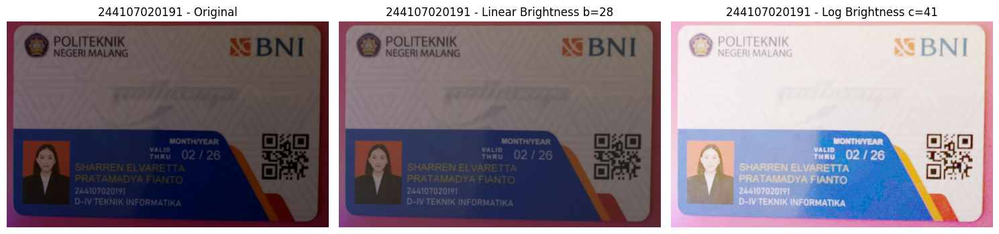

In [24]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Original')
plt.axis('off')

# Linear Brightness
plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(linear_image, cv.COLOR_BGR2RGB))
plt.title(
    NIM + ' - Linear Brightness b=' + str(PARAM['b'])
)
plt.axis('off')

# Logarithmic Brightness
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(log_image, cv.COLOR_BGR2RGB))
plt.title(
    NIM + ' - Log Brightness c=' + str(PARAM['c'])
)
plt.axis('off')

plt.tight_layout()
plt.show()

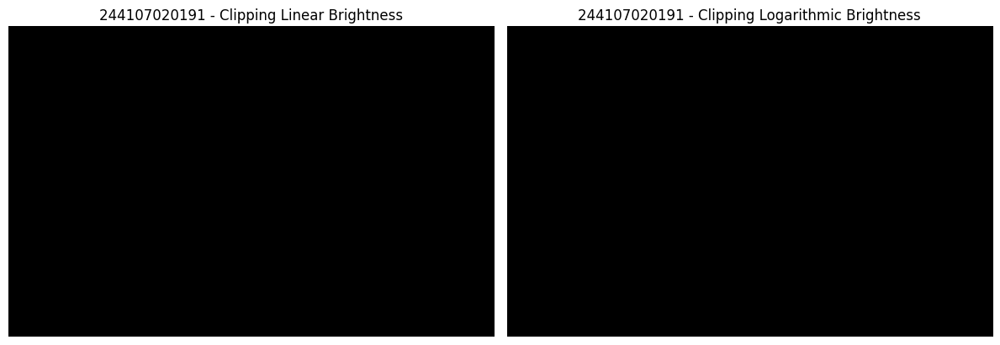

In [25]:
# Mendeteksi pixel putih penuh / clipping

linear_clipping = np.all(linear_image == 255, axis=2)
log_clipping = np.all(log_image == 255, axis=2)

plt.figure(figsize=(12, 5))

# Clipping Linear
plt.subplot(1, 2, 1)
plt.imshow(linear_clipping, cmap='gray')
plt.title(NIM + ' - Clipping Linear Brightness')
plt.axis('off')

# Clipping Log
plt.subplot(1, 2, 2)
plt.imshow(log_clipping, cmap='gray')
plt.title(NIM + ' - Clipping Logarithmic Brightness')
plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
# Menghitung jumlah dan persentase clipping

total_pixels = original.shape[0] * original.shape[1]

jumlah_linear = np.sum(linear_clipping)
jumlah_log = np.sum(log_clipping)

persen_linear = (jumlah_linear / total_pixels) * 100
persen_log = (jumlah_log / total_pixels) * 100

print('=== CLIPPING ===')

print('Linear Brightness')
print('Jumlah pixel clipping :', jumlah_linear)
print('Persentase clipping   :', f'{persen_linear:.4f}%')

print()

print('Logarithmic Brightness')
print('Jumlah pixel clipping :', jumlah_log)
print('Persentase clipping   :', f'{persen_log:.4f}%')

=== CLIPPING ===
Linear Brightness
Jumlah pixel clipping : 0
Persentase clipping   : 0.0000%

Logarithmic Brightness
Jumlah pixel clipping : 0
Persentase clipping   : 0.0000%


| Metode                 | Parameter | Keterbacaan NIM   | Clipping putih penuh |
| ---------------------- | --------: | ----------------- | -------------------- |
| Linear Brightness      |  `b = 28` | Lebih rendah      | Tidak ada            |
| Logarithmic Brightness |  `c = 41` | **Lebih terbaca** | Tidak ada            |

* Pada kedua metode tidak terdapat bagian yang mengalami clipping putih penuh. Mask clipping berwarna hitam seluruhnya, yang menunjukkan bahwa tidak ada pixel dengan nilai RGB (255,255,255).

# Tugas Praktikum No. 4

In [28]:
# Membaca KTM1c.jpg
ktm1c = cv.imread(
    os.path.join(BASE, 'KTM1c.jpg')
)

if ktm1c is None:
    print('Error: KTM1c.jpg tidak berhasil dibaca')
else:
    print('KTM1c berhasil dibaca')
    print('Shape:', ktm1c.shape)

KTM1c berhasil dibaca
Shape: (998, 1600, 3)


In [29]:
# Grayscale - Averaging

b_channel = ktm1c[:, :, 0].astype(np.float32)
g_channel = ktm1c[:, :, 1].astype(np.float32)
r_channel = ktm1c[:, :, 2].astype(np.float32)

gray_averaging = (
    r_channel + g_channel + b_channel
) / 3

gray_averaging = np.clip(
    gray_averaging,
    0,
    255
).astype(np.uint8)

print('Averaging selesai.')

Averaging selesai.


In [30]:
# Grayscale - Lightness

maximum = np.maximum.reduce([
    r_channel,
    g_channel,
    b_channel
])

minimum = np.minimum.reduce([
    r_channel,
    g_channel,
    b_channel
])

gray_lightness = (
    maximum + minimum
) / 2

gray_lightness = np.clip(
    gray_lightness,
    0,
    255
).astype(np.uint8)

print('Lightness selesai.')

Lightness selesai.


In [31]:
# Grayscale - Luminance
# Standar Rec. 709

gray_luminance = (
    0.21 * r_channel +
    0.72 * g_channel +
    0.07 * b_channel
)

gray_luminance = np.clip(
    gray_luminance,
    0,
    255
).astype(np.uint8)

print('Luminance selesai.')
print('Standar: Rec. 709')

Luminance selesai.
Standar: Rec. 709


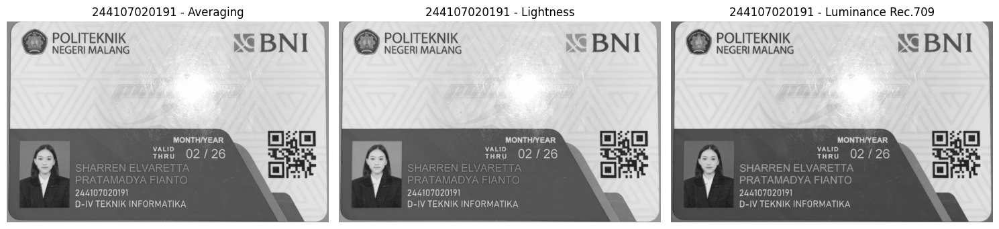

In [32]:
plt.figure(figsize=(15, 5))

# Averaging
plt.subplot(1, 3, 1)
plt.imshow(gray_averaging, cmap='gray')
plt.title(NIM + ' - Averaging')
plt.axis('off')

# Lightness
plt.subplot(1, 3, 2)
plt.imshow(gray_lightness, cmap='gray')
plt.title(NIM + ' - Lightness')
plt.axis('off')

# Luminance
plt.subplot(1, 3, 3)
plt.imshow(gray_luminance, cmap='gray')
plt.title(NIM + ' - Luminance Rec.709')
plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
# Statistik intensitas grayscale

methods = {
    'Averaging': gray_averaging,
    'Lightness': gray_lightness,
    'Luminance': gray_luminance
}

for name, image in methods.items():
    mean = np.mean(image)
    std = np.std(image)

    print(
        f'{name:12s} | '
        f'Rata-rata = {mean:.2f} | '
        f'Simpangan baku = {std:.2f}'
    )

Averaging    | Rata-rata = 165.55 | Simpangan baku = 65.37
Lightness    | Rata-rata = 166.91 | Simpangan baku = 65.12
Luminance    | Rata-rata = 159.34 | Simpangan baku = 69.34


In [34]:
import pandas as pd

data_statistik = []

for name, image in methods.items():
    data_statistik.append({
        'Metode': name,
        'Rata-rata Intensitas': np.mean(image),
        'Simpangan Baku': np.std(image)
    })

df_statistik = pd.DataFrame(data_statistik)

df_statistik['Rata-rata Intensitas'] = \
    df_statistik['Rata-rata Intensitas'].round(2)

df_statistik['Simpangan Baku'] = \
    df_statistik['Simpangan Baku'].round(2)

df_statistik

,Metode,Rata-rata Intensitas,Simpangan Baku
0,Averaging,165.55,65.37
1,Lightness,166.91,65.12
2,Luminance,159.34,69.34


In [35]:
# Luminance Rec. 601
gray_luminance_601 = (
    0.299 * r_channel +
    0.587 * g_channel +
    0.114 * b_channel
)

gray_luminance_601 = np.clip(
    gray_luminance_601,
    0,
    255
).astype(np.uint8)

print('Luminance Rec. 601 selesai.')

Luminance Rec. 601 selesai.


In [36]:
# Selisih Rec. 709 dan Rec. 601

difference_luminance = cv.absdiff(
    gray_luminance,
    gray_luminance_601
)

print(
    'Rata-rata selisih:',
    np.mean(difference_luminance)
)

print(
    'Simpangan baku selisih:',
    np.std(difference_luminance)
)

print(
    'Selisih maksimum:',
    np.max(difference_luminance)
)

Rata-rata selisih: 2.4030316883767533
Simpangan baku selisih: 3.488186073938817
Selisih maksimum: 18


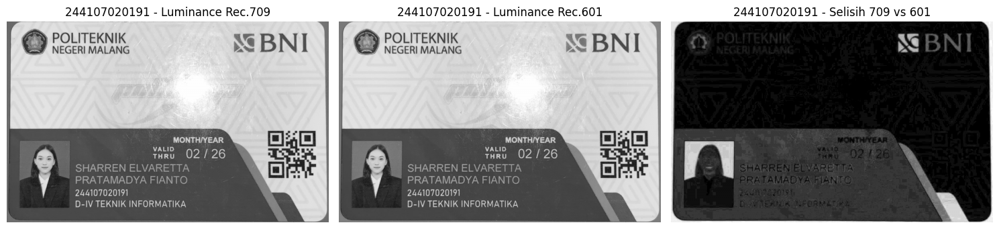

In [37]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_luminance, cmap='gray')
plt.title(NIM + ' - Luminance Rec.709')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_luminance_601, cmap='gray')
plt.title(NIM + ' - Luminance Rec.601')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(difference_luminance, cmap='gray')
plt.title(NIM + ' - Selisih 709 vs 601')
plt.axis('off')

plt.tight_layout()
plt.show()

* Hasil numeriknya menunjukkan Luminance memiliki penyebaran intensitas terbesar. Untuk klaim "pemisahan teks dan latar paling jelas", pastikan juga gambar Averaging, Lightness, dan Luminance yang kamu tampilkan memang mendukung pengamatan tersebut.

# Tugas Praktikum No. 5

In [38]:
obj = cv.imread(
    os.path.join(BASE, 'OBJ1.jpg')
)

if obj is None:
    print('Error: OBJ1.jpg tidak berhasil dibaca')
else:
    print('OBJ1.jpg berhasil dibaca')
    print('Shape:', obj.shape)

OBJ1.jpg berhasil dibaca
Shape: (1280, 960, 3)


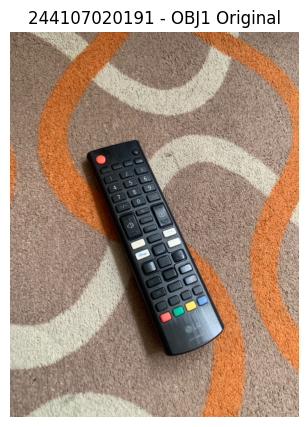

In [39]:
plt.figure(figsize=(7, 5))

plt.imshow(cv.cvtColor(obj, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - OBJ1 Original')
plt.axis('off')

plt.show()

In [40]:
# Konversi dari BGR ke HSV

obj_hsv = cv.cvtColor(
    obj,
    cv.COLOR_BGR2HSV
)

print('Konversi BGR ke HSV berhasil.')

Konversi BGR ke HSV berhasil.


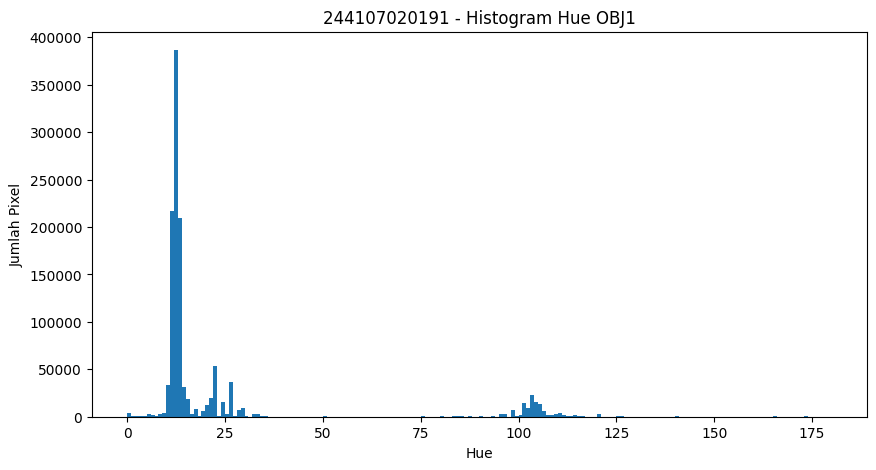

In [41]:
# Histogram Hue

hue = obj_hsv[:, :, 0]

plt.figure(figsize=(10, 5))

plt.hist(
    hue.ravel(),
    bins=180,
    range=(0, 180)
)

plt.title(NIM + ' - Histogram Hue OBJ1')
plt.xlabel('Hue')
plt.ylabel('Jumlah Pixel')

plt.show()

In [42]:
lower_orange = np.array([5, 80, 50])
upper_orange = np.array([25, 255, 255])

# Membuat mask berdasarkan range HSV
mask_orange = cv.inRange(
    obj_hsv,
    lower_orange,
    upper_orange
)

print('Range HSV warna oranye:')
print('Lower:', lower_orange)
print('Upper:', upper_orange)

Range HSV warna oranye:
Lower: [ 5 80 50]
Upper: [ 25 255 255]


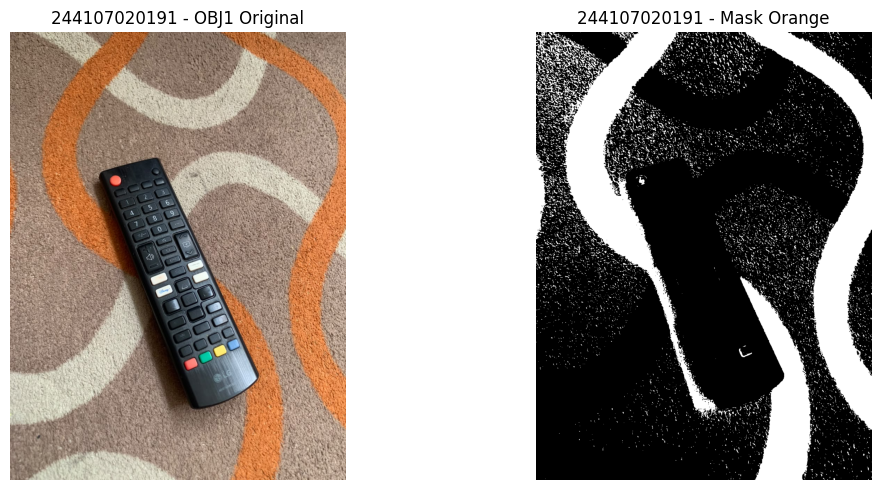

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(obj, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - OBJ1 Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_orange, cmap='gray')
plt.title(NIM + ' - Mask Orange')
plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
# Membuat grayscale dari OBJ1

gray_obj = cv.cvtColor(
    obj,
    cv.COLOR_BGR2GRAY
)

# Mengubah grayscale menjadi 3 channel BGR
gray_obj_bgr = cv.cvtColor(
    gray_obj,
    cv.COLOR_GRAY2BGR
)

print('Grayscale berhasil dibuat.')

Grayscale berhasil dibuat.


In [47]:
# Range HSV warna oranye

lower_orange = np.array([5, 80, 50])
upper_orange = np.array([25, 255, 255])

# Membuat mask
mask_orange = cv.inRange(
    obj_hsv,
    lower_orange,
    upper_orange
)

print('Mask oranye berhasil dibuat.')

Mask oranye berhasil dibuat.


In [48]:
# Menggabungkan:
# - warna oranye tetap berwarna
# - bagian lainnya menjadi grayscale

result_orange = np.where(
    mask_orange[:, :, np.newaxis] > 0,
    obj,
    gray_obj_bgr
).astype(np.uint8)

print('Result orange berhasil dibuat.')

Result orange berhasil dibuat.


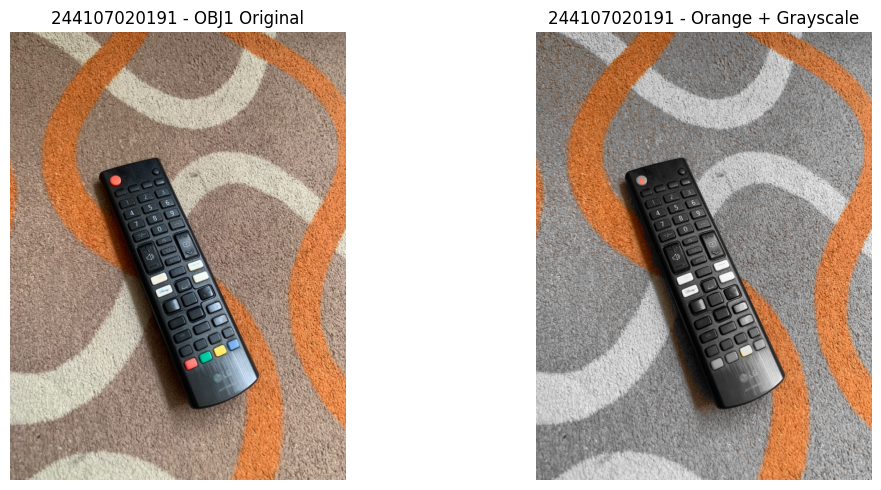

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(obj, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - OBJ1 Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result_orange, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Orange + Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
# Range dipersempit
lower_narrow = np.array([10, 120, 80])
upper_narrow = np.array([20, 255, 255])

# Range normal
lower_normal = np.array([5, 80, 50])
upper_normal = np.array([25, 255, 255])

# Range diperlebar
lower_wide = np.array([0, 50, 30])
upper_wide = np.array([35, 255, 255])

# Membuat mask
mask_narrow = cv.inRange(
    obj_hsv,
    lower_narrow,
    upper_narrow
)

mask_normal = cv.inRange(
    obj_hsv,
    lower_normal,
    upper_normal
)

mask_wide = cv.inRange(
    obj_hsv,
    lower_wide,
    upper_wide
)

print('Semua mask berhasil dibuat.')

Semua mask berhasil dibuat.


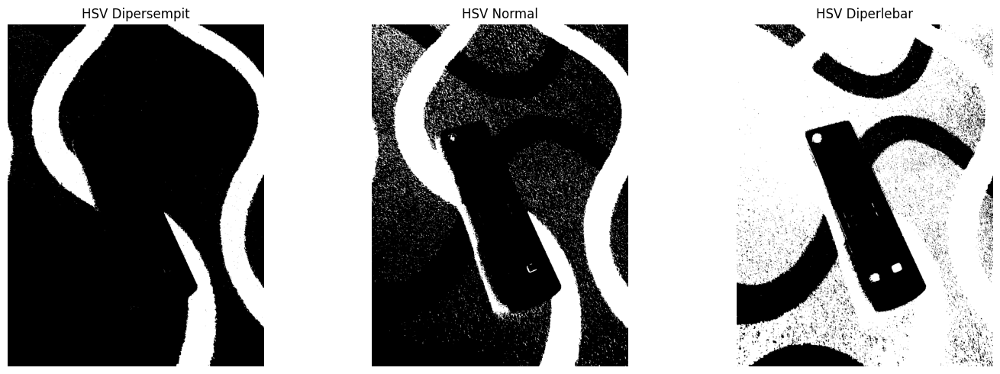

In [51]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_narrow, cmap='gray')
plt.title('HSV Dipersempit')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_normal, cmap='gray')
plt.title('HSV Normal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_wide, cmap='gray')
plt.title('HSV Diperlebar')
plt.axis('off')

plt.tight_layout()
plt.show()

In [52]:
result_narrow = np.where(
    mask_narrow[:, :, np.newaxis] > 0,
    obj,
    gray_obj_bgr
).astype(np.uint8)

result_normal = np.where(
    mask_normal[:, :, np.newaxis] > 0,
    obj,
    gray_obj_bgr
).astype(np.uint8)

result_wide = np.where(
    mask_wide[:, :, np.newaxis] > 0,
    obj,
    gray_obj_bgr
).astype(np.uint8)

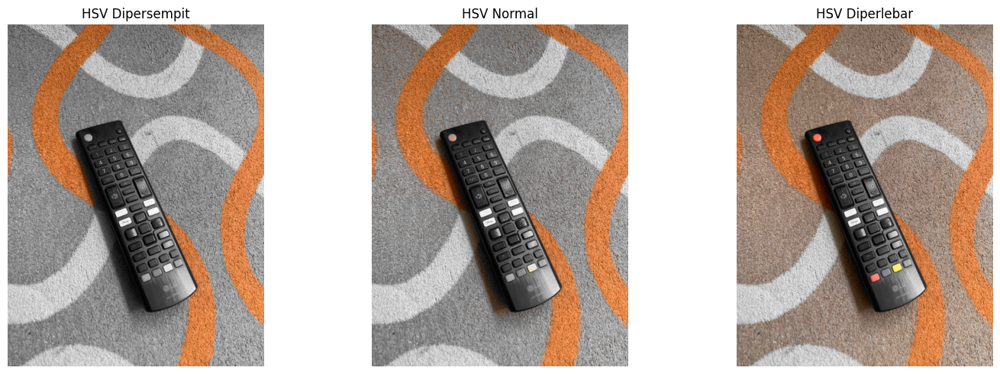

In [53]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(result_narrow, cv.COLOR_BGR2RGB))
plt.title('HSV Dipersempit')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(result_normal, cv.COLOR_BGR2RGB))
plt.title('HSV Normal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(result_wide, cv.COLOR_BGR2RGB))
plt.title('HSV Diperlebar')
plt.axis('off')

plt.tight_layout()
plt.show()

Pada percobaan ini digunakan metode HSV color filtering untuk mempertahankan warna oranye pada OBJ1.jpg, sedangkan bagian lainnya diubah menjadi grayscale. Range HSV yang digunakan pada kondisi normal adalah Lower [5, 80, 50] dan Upper [25, 255, 255].

Ketika range HSV dipersempit menjadi Lower [10, 120, 80] dan Upper [20, 255, 255], hanya warna oranye yang memiliki karakteristik HSV lebih dekat dengan warna target yang dipertahankan. Akibatnya, sebagian variasi warna oranye tidak terdeteksi dan berubah menjadi grayscale.

Ketika range HSV diperlebar menjadi Lower [0, 50, 30] dan Upper [35, 255, 255], lebih banyak variasi warna yang masuk ke dalam mask. Hal tersebut menyebabkan area dengan karakteristik warna yang mendekati oranye lebih banyak dipertahankan dalam bentuk warna.

* Dari ketiga percobaan tersebut, range normal memberikan hasil yang cukup sesuai untuk mempertahankan warna oranye pada objek target tanpa terlalu banyak memasukkan warna lain.

# Tugas Praktikum No. 6

In [54]:
original_gamma = cv.imread(
    os.path.join(BASE, 'KTM1a.jpg')
)

if original_gamma is None:
    print('Error: KTM1a.jpg tidak berhasil dibaca')
else:
    print('KTM1a berhasil dibaca')
    print('Shape:', original_gamma.shape)

KTM1a berhasil dibaca
Shape: (1024, 1600, 3)


In [55]:
def gamma_correction(image, gamma):
    """
    Gamma Correction menggunakan rumus:
    s = 255 * (r / 255) ** (1 / gamma)
    """

    # Konversi ke float
    image_float = image.astype(np.float32)

    # Gamma correction
    corrected = 255.0 * (
        image_float / 255.0
    ) ** (1.0 / gamma)

    # Pastikan berada pada rentang 0-255
    corrected = np.clip(
        corrected,
        0,
        255
    )

    return corrected.astype(np.uint8)

In [56]:
gamma_nim = PARAM['gamma']

print('Gamma berdasarkan NIM =', gamma_nim)

gamma_165 = gamma_correction(
    original_gamma,
    gamma_nim
)

Gamma berdasarkan NIM = 1.65


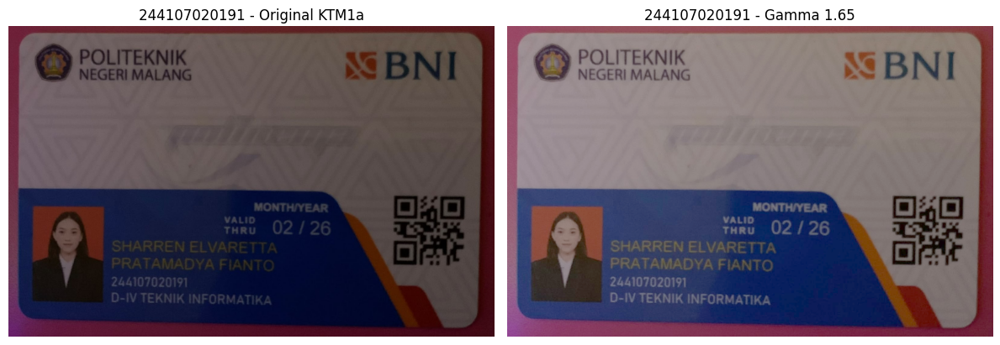

In [57]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    cv.cvtColor(original_gamma, cv.COLOR_BGR2RGB)
)
plt.title(NIM + ' - Original KTM1a')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(
    cv.cvtColor(gamma_165, cv.COLOR_BGR2RGB)
)
plt.title(
    NIM + ' - Gamma ' + str(gamma_nim)
)
plt.axis('off')

plt.tight_layout()
plt.show()

In [61]:
# Nilai gamma yang akan diuji
gamma_values = [
    1.00,
    1.25,
    1.50,
    1.65,
    2.00,
    2.50
]

print('Nilai gamma yang diuji:')
print(gamma_values)

Nilai gamma yang diuji:
[1.0, 1.25, 1.5, 1.65, 2.0, 2.5]


In [62]:
gamma_results = {}

for gamma in gamma_values:
    gamma_results[gamma] = gamma_correction(
        original_gamma,
        gamma
    )

print('Semua hasil gamma berhasil dibuat.')

Semua hasil gamma berhasil dibuat.


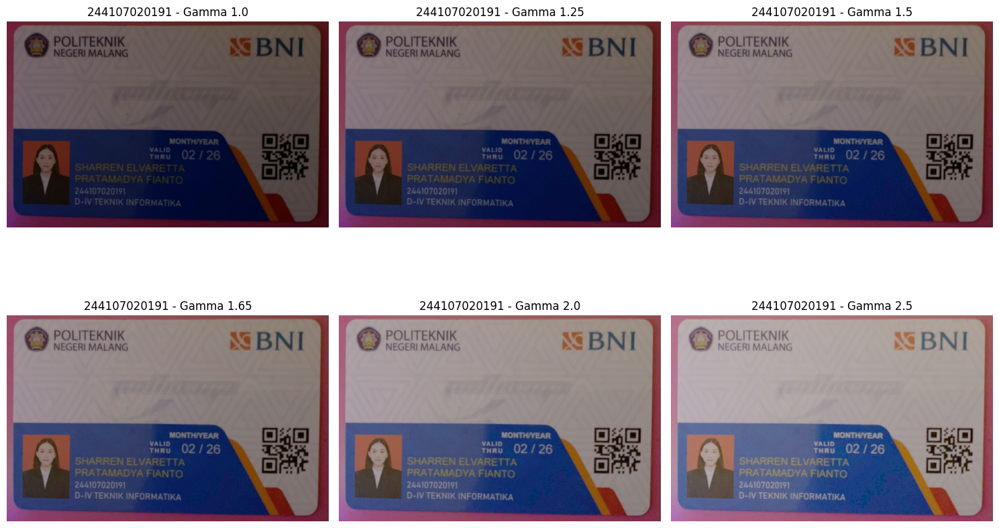

In [63]:
plt.figure(figsize=(15, 10))

for i, gamma in enumerate(gamma_values):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        cv.cvtColor(
            gamma_results[gamma],
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(
        NIM + ' - Gamma ' + str(gamma)
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Nilai gamma yang diuji adalah 1.00, 1.25, 1.50, 1.65, 2.00, dan 2.50. Berdasarkan hasil pengamatan, γ = 1.65 dipilih karena membuat NIM dan nama pada kartu lebih terbaca dengan tingkat kecerahan yang cukup. Nilai gamma dapat berbeda antar mahasiswa karena kondisi pencahayaan dan tingkat kecerahan citra yang digunakan berbeda.

# Tugas Praktikum No. 7

In [64]:
original_depth = cv.imread(
    os.path.join(BASE, 'KTM1b.jpg'),
    cv.IMREAD_GRAYSCALE
)

if original_depth is None:
    print('Error: KTM1b.jpg tidak berhasil dibaca')
else:
    print('KTM1b berhasil dibaca')
    print('Shape:', original_depth.shape)

KTM1b berhasil dibaca
Shape: (1014, 1600)


In [65]:
def image_depth(image, bit_depth):
    level = 255 / (pow(2, bit_depth) - 1)

    depth_image = np.round(
        image / level
    ) * level

    depth_image = np.clip(
        depth_image,
        0,
        255
    )

    return depth_image.astype(np.uint8)

In [66]:
depth_results = {}

for bit_depth in range(1, 8):
    depth_results[bit_depth] = image_depth(
        original_depth,
        bit_depth
    )

print('Image depth 1-7 bit berhasil dibuat.')

Image depth 1-7 bit berhasil dibuat.


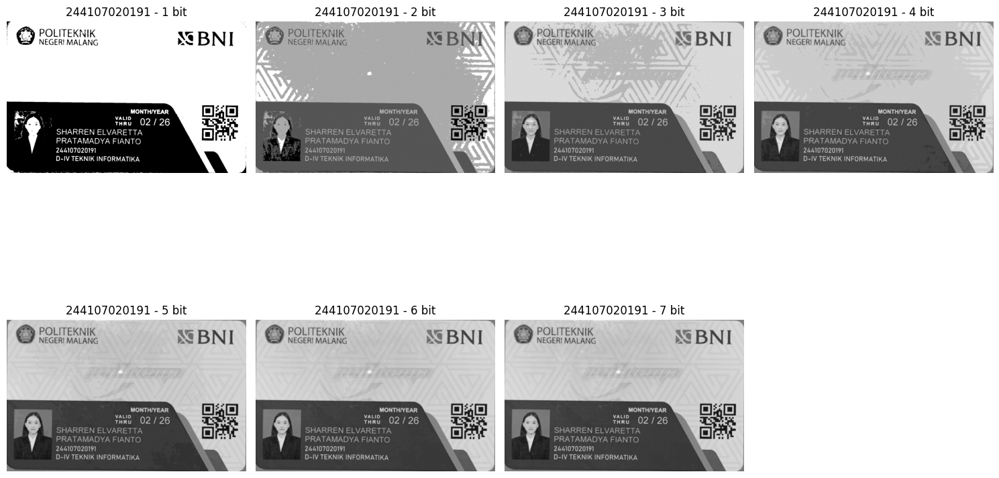

In [67]:
plt.figure(figsize=(15, 10))

for i, bit_depth in enumerate(range(1, 8)):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        depth_results[bit_depth],
        cmap='gray'
    )

    plt.title(
        NIM + ' - ' + str(bit_depth) + ' bit'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

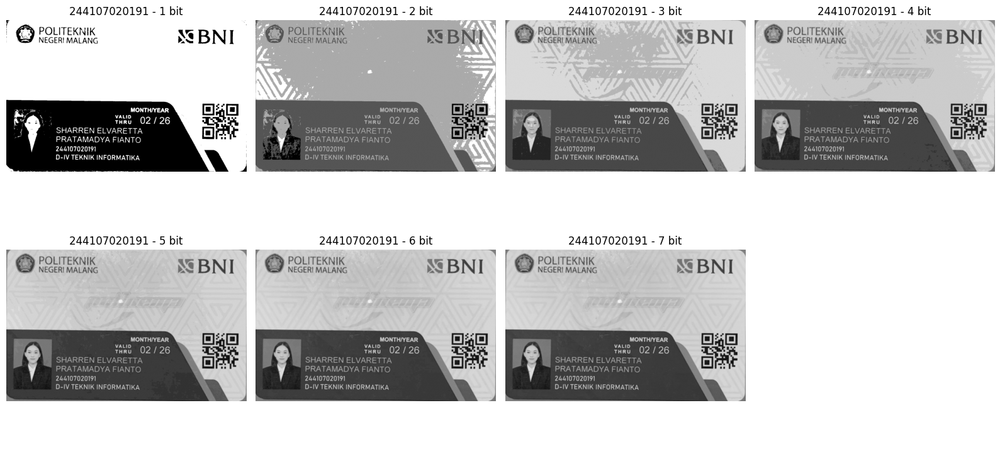

In [68]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8)
)

axes = axes.ravel()

for i, bit_depth in enumerate(range(1, 8)):

    axes[i].imshow(
        depth_results[bit_depth],
        cmap='gray'
    )

    axes[i].set_title(
        f'{NIM} - {bit_depth} bit'
    )

    axes[i].axis('off')

# Matikan subplot terakhir
axes[7].axis('off')

plt.tight_layout()
plt.show()

Pada citra KTM1b, nama dan NIM mulai dapat terbaca pada kedalaman 3 bit. Semakin tinggi kedalaman bit, semakin banyak tingkat keabuan yang tersedia sehingga detail tulisan menjadi semakin jelas. Berdasarkan perhitungan NIM, kedalaman yang diperoleh adalah 7 bit.

# Tugas Praktikum No. 8

In [69]:
import os
import glob
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

GALAXY_PATH = '/content/drive/MyDrive/PCVK IMAGES/galaxy.jpg'
NOISE_PATH = '/content/drive/MyDrive/PCVK IMAGES/noises'

# Cek galaxy
original_galaxy = cv.imread(GALAXY_PATH)

if original_galaxy is None:
    print('❌ galaxy.jpg tidak ditemukan')
else:
    print('✅ galaxy.jpg berhasil dibaca')
    print('Shape:', original_galaxy.shape)

# Cari semua file noise
noise_files = sorted(
    glob.glob(os.path.join(NOISE_PATH, '*'))
)

print('Jumlah file di folder noises:', len(noise_files))

# Tampilkan 5 file pertama
print('\n5 file pertama:')
for f in noise_files[:5]:
    print(os.path.basename(f))

✅ galaxy.jpg berhasil dibaca
Shape: (256, 310, 3)
Jumlah file di folder noises: 101

5 file pertama:
1.jpg
10.jpg
100.jpg
11.jpg
12.jpg


In [70]:
# Cek semua file di folder noises

for i, f in enumerate(noise_files, start=1):
    print(i, os.path.basename(f))

1 1.jpg
2 10.jpg
3 100.jpg
4 11.jpg
5 12.jpg
6 13.jpg
7 14.jpg
8 15.jpg
9 16.jpg
10 17.jpg
11 18.jpg
12 19.jpg
13 2.jpg
14 20.jpg
15 21.jpg
16 22.jpg
17 23.jpg
18 24.jpg
19 25.jpg
20 26.jpg
21 27.jpg
22 28.jpg
23 29.jpg
24 3.jpg
25 30.jpg
26 31.jpg
27 32.jpg
28 33.jpg
29 34.jpg
30 35.jpg
31 36.jpg
32 37.jpg
33 38.jpg
34 39.jpg
35 4.jpg
36 40.jpg
37 41.jpg
38 42.jpg
39 43.jpg
40 44.jpg
41 45.jpg
42 46.jpg
43 47.jpg
44 48.jpg
45 49.jpg
46 5.jpg
47 50.jpg
48 51.jpg
49 52.jpg
50 53.jpg
51 54.jpg
52 55.jpg
53 56.jpg
54 57.jpg
55 58.jpg
56 59.jpg
57 6.jpg
58 60.jpg
59 61.jpg
60 62.jpg
61 63.jpg
62 64.jpg
63 65.jpg
64 66.jpg
65 67.jpg
66 68.jpg
67 69.jpg
68 7.jpg
69 70.jpg
70 71.jpg
71 72.jpg
72 73.jpg
73 74.jpg
74 75.jpg
75 76.jpg
76 77.jpg
77 78.jpg
78 79.jpg
79 8.jpg
80 80.jpg
81 81.jpg
82 82.jpg
83 83.jpg
84 84.jpg
85 85.jpg
86 86.jpg
87 87.jpg
88 88.jpg
89 89.jpg
90 9.jpg
91 90.jpg
92 91.jpg
93 92.jpg
94 93.jpg
95 94.jpg
96 95.jpg
97 96.jpg
98 97.jpg
99 98.jpg
100 99.jpg
101 _Thumbs.db


In [71]:
valid_noise_files = []

for f in noise_files:
    img = cv.imread(f)

    if img is not None:
        valid_noise_files.append(f)

print("File yang berhasil dibaca sebagai gambar:", len(valid_noise_files))

File yang berhasil dibaca sebagai gambar: 100


In [72]:
noise_images = []

for f in valid_noise_files:
    img = cv.imread(f)

    if img is not None:
        noise_images.append(img)

print('Jumlah citra noise:', len(noise_images))

Jumlah citra noise: 100


In [73]:
print('Ukuran galaxy :', original_galaxy.shape)
print('Ukuran noise  :', noise_images[0].shape)

Ukuran galaxy : (256, 310, 3)
Ukuran noise  : (256, 310, 3)


In [74]:
def average_denoising(images):
    stack = np.stack(
        images,
        axis=0
    ).astype(np.float32)

    average_image = np.mean(
        stack,
        axis=0
    )

    average_image = np.clip(
        average_image,
        0,
        255
    )

    return average_image.astype(np.uint8)

In [75]:
from math import log10, sqrt

def PSNR(img1, img2):

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mse = np.mean(
        (img1 - img2) ** 2
    )

    if mse == 0:
        return float('inf')

    return 20 * log10(
        255.0 / sqrt(mse)
    )

In [76]:
jumlah_citra = [10, 20, 40, 80, 100]

hasil_denoising = {}
hasil_psnr = {}

for jumlah in jumlah_citra:

    # Ambil sejumlah noise
    images = noise_images[:jumlah]

    # Average denoising
    denoised = average_denoising(images)

    # Hitung PSNR terhadap galaxy asli
    psnr_value = PSNR(
        original_galaxy,
        denoised
    )

    hasil_denoising[jumlah] = denoised
    hasil_psnr[jumlah] = psnr_value

    print(
        f'{jumlah} citra -> PSNR = {psnr_value:.4f} dB'
    )

10 citra -> PSNR = 19.7356 dB
20 citra -> PSNR = 19.8405 dB
40 citra -> PSNR = 19.8928 dB
80 citra -> PSNR = 19.9159 dB
100 citra -> PSNR = 19.9220 dB


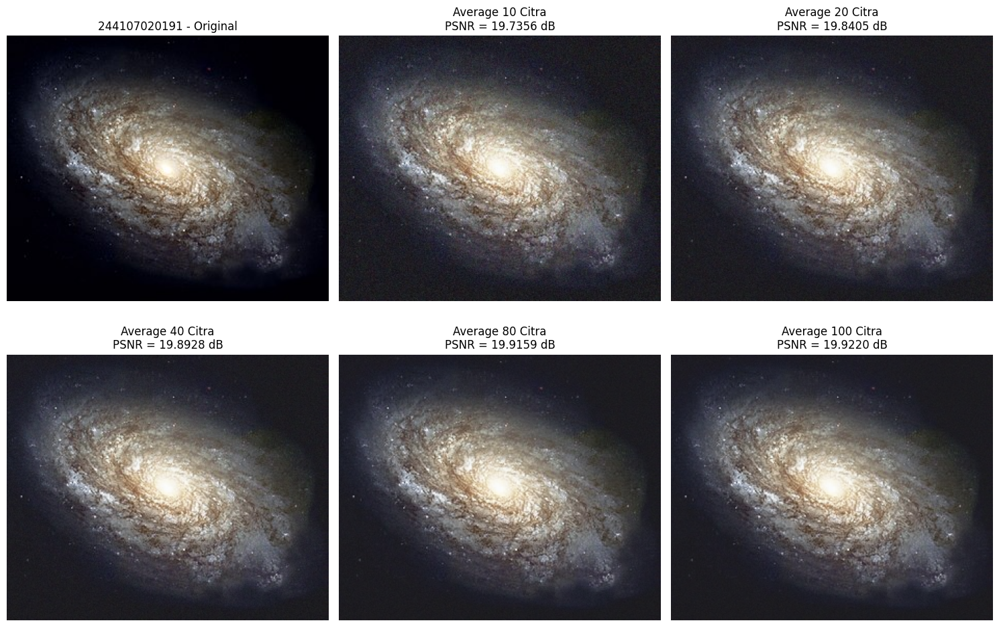

In [77]:
plt.figure(figsize=(15, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(
    cv.cvtColor(original_galaxy, cv.COLOR_BGR2RGB)
)
plt.title(NIM + ' - Original')
plt.axis('off')

# Hasil average denoising
for i, jumlah in enumerate(jumlah_citra):

    plt.subplot(2, 3, i + 2)

    plt.imshow(
        cv.cvtColor(
            hasil_denoising[jumlah],
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(
        f'Average {jumlah} Citra\n'
        f'PSNR = {hasil_psnr[jumlah]:.4f} dB'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Peningkatan jumlah citra tidak selalu memberikan peningkatan PSNR yang signifikan. PSNR meningkat dari 19.7356 dB (10 citra) menjadi 19.9220 dB (100 citra), tetapi peningkatannya semakin kecil. Peningkatan mulai tidak terlalu signifikan setelah 40 citra, karena penambahan dari 40 ke 80 dan 100 citra hanya meningkatkan PSNR sedikit. Jadi, semakin banyak citra yang dirata-ratakan memang meningkatkan kualitas denoising, tetapi manfaat tambahannya semakin kecil.

# Tugas Praktikum No. 9

In [78]:
ktm1d = cv.imread(
    os.path.join(BASE, 'KTM1d.jpg')
)

if ktm1d is None:
    print('❌ KTM1d.jpg tidak ditemukan')
else:
    print('✅ KTM1d berhasil dibaca')
    print('Shape:', ktm1d.shape)

✅ KTM1d berhasil dibaca
Shape: (1050, 1619, 3)


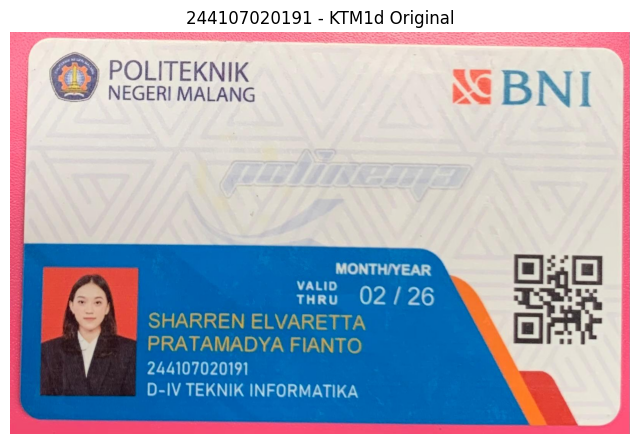

In [79]:
plt.figure(figsize=(8, 6))

plt.imshow(
    cv.cvtColor(ktm1d, cv.COLOR_BGR2RGB)
)

plt.title(NIM + ' - KTM1d Original')
plt.axis('off')

plt.show()

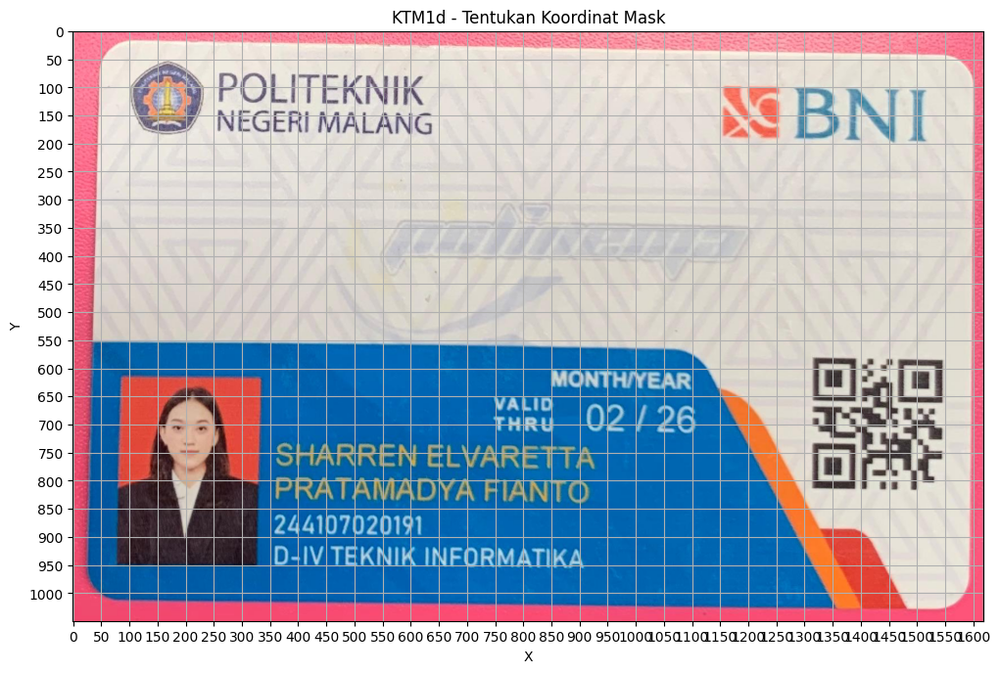

In [80]:
plt.figure(figsize=(12, 8))

plt.imshow(
    cv.cvtColor(ktm1d, cv.COLOR_BGR2RGB)
)

plt.title('KTM1d - Tentukan Koordinat Mask')
plt.xlabel('X')
plt.ylabel('Y')

# Grid setiap 50 pixel
plt.xticks(np.arange(0, ktm1d.shape[1], 50))
plt.yticks(np.arange(0, ktm1d.shape[0], 50))

plt.grid()

plt.show()

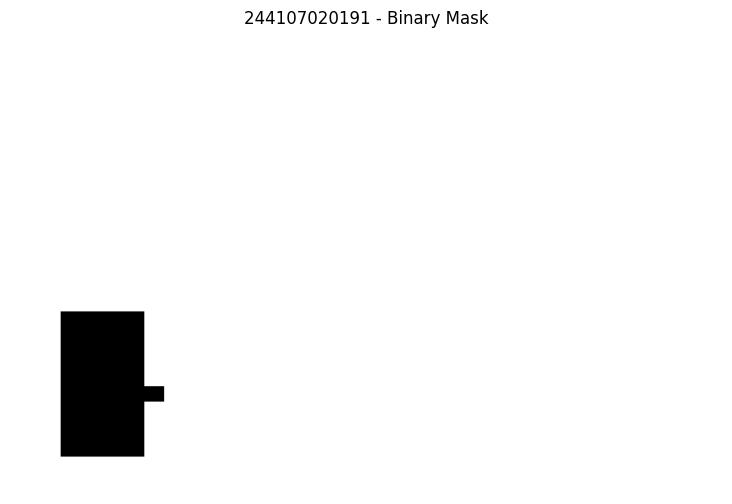

In [81]:
# Membuat mask biner
mask = np.ones(ktm1d.shape[:2], dtype=np.uint8) * 255

# Area foto wajah dibuat hitam
x1_face, y1_face = 115, 635
x2_face, y2_face = 305, 965
mask[y1_face:y2_face, x1_face:x2_face] = 0

# Area NIM dibuat hitam
x1_nim, y1_nim = 205, 805
x2_nim, y2_nim = 350, 840
mask[y1_nim:y2_nim, x1_nim:x2_nim] = 0

# Tampilkan mask
plt.figure(figsize=(10, 6))
plt.imshow(mask, cmap='gray')
plt.title(NIM + ' - Binary Mask')
plt.axis('off')
plt.show()

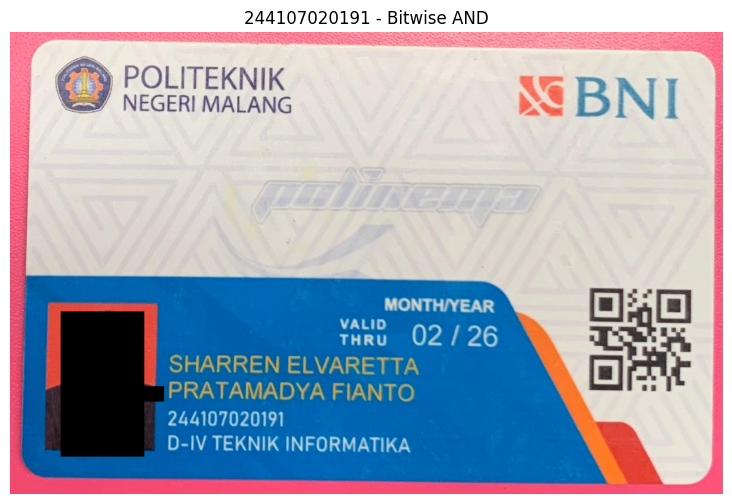

In [82]:
hasil_and = cv.bitwise_and(ktm1d, ktm1d, mask=mask)

plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(hasil_and, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Bitwise AND')
plt.axis('off')
plt.show()

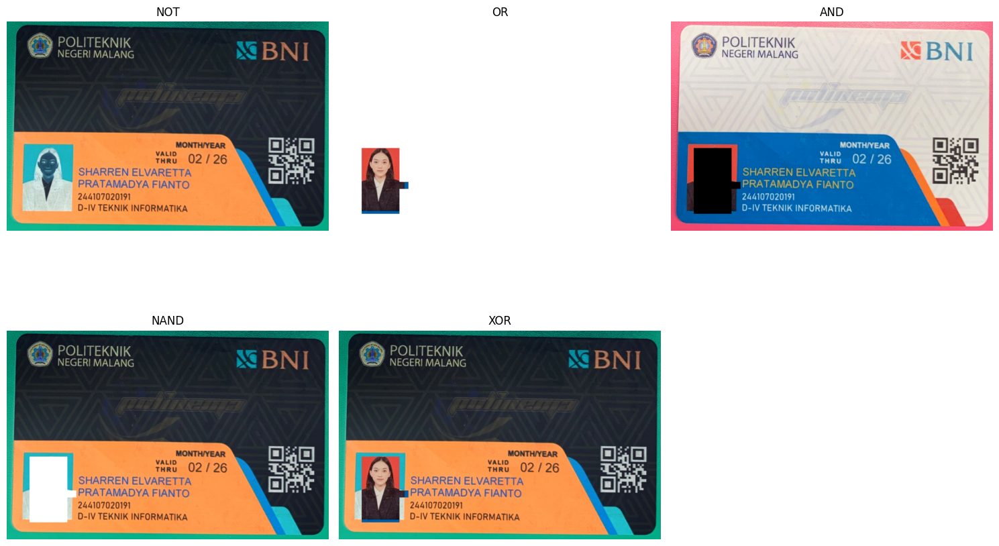

In [83]:
# NOT
hasil_not = cv.bitwise_not(ktm1d)

# OR
hasil_or = cv.bitwise_or(ktm1d, cv.cvtColor(mask, cv.COLOR_GRAY2BGR))

# AND
hasil_and = cv.bitwise_and(ktm1d, cv.cvtColor(mask, cv.COLOR_GRAY2BGR))

# NAND = NOT dari AND
hasil_nand = cv.bitwise_not(hasil_and)

# XOR
hasil_xor = cv.bitwise_xor(ktm1d, cv.cvtColor(mask, cv.COLOR_GRAY2BGR))

# Tampilkan semua hasil
hasil_operasi = [
    ('NOT', hasil_not),
    ('OR', hasil_or),
    ('AND', hasil_and),
    ('NAND', hasil_nand),
    ('XOR', hasil_xor)
]

plt.figure(figsize=(15, 10))

for i, (nama, hasil) in enumerate(hasil_operasi):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    plt.title(nama)
    plt.axis('off')

plt.tight_layout()
plt.show()

AND menghasilkan citra dengan area wajah dan NIM menjadi hitam sehingga dapat digunakan untuk menyamarkan data pribadi. NOT membalik nilai piksel sehingga citra terlihat seperti negatif. OR menghasilkan sebagian besar area menjadi putih karena mask bernilai 255. NAND merupakan kebalikan dari hasil AND. XOR menghasilkan perubahan nilai piksel pada area yang berbeda antara citra dan mask. Dari beberapa operasi tersebut, AND paling sesuai untuk masking karena dapat mempertahankan bagian citra yang tidak ditutupi dan menghilangkan area yang ingin disamarkan.

# Tugas Praktikum No. 10

✅ NIGHT1.jpg berhasil dibaca
Shape: (1200, 1600, 3)


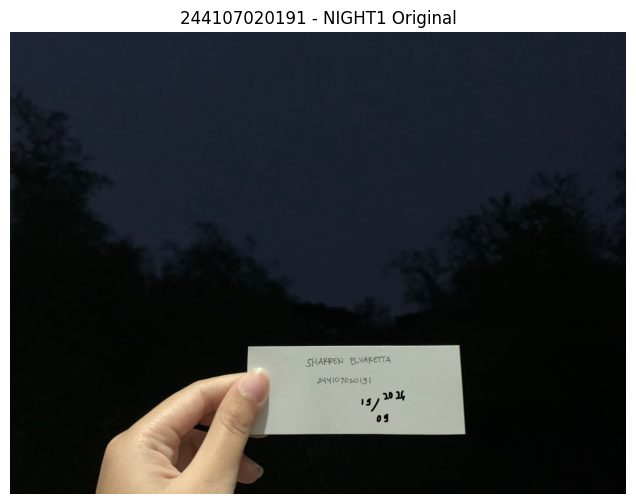

In [84]:
# Membaca citra malam
night = cv.imread(
    os.path.join(BASE, 'NIGHT1.jpg')
)

if night is None:
    print('❌ NIGHT1.jpg tidak ditemukan')
else:
    print('✅ NIGHT1.jpg berhasil dibaca')
    print('Shape:', night.shape)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(night, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - NIGHT1 Original')
    plt.axis('off')
    plt.show()

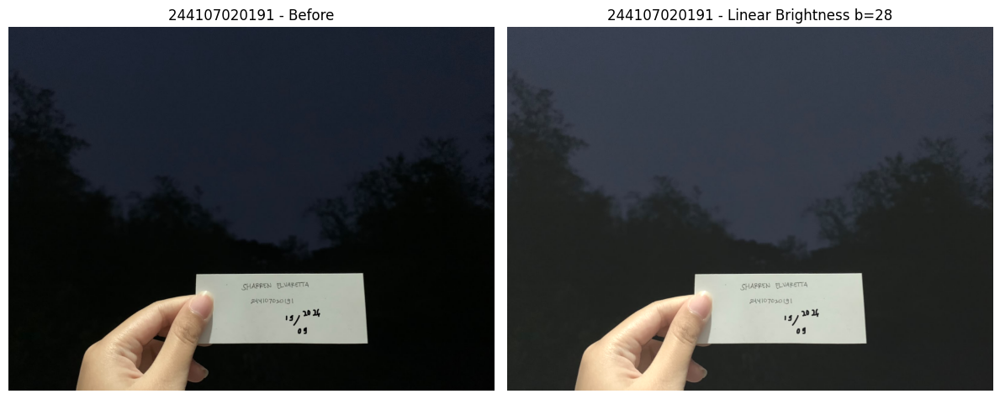

In [85]:
# Linear Brightness berdasarkan parameter NIM
b = PARAM['b']

brightness_28 = cv.add(night, np.full(night.shape, b, dtype=np.uint8))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(night, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(brightness_28, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Linear Brightness b=' + str(b))
plt.axis('off')

plt.tight_layout()
plt.show()

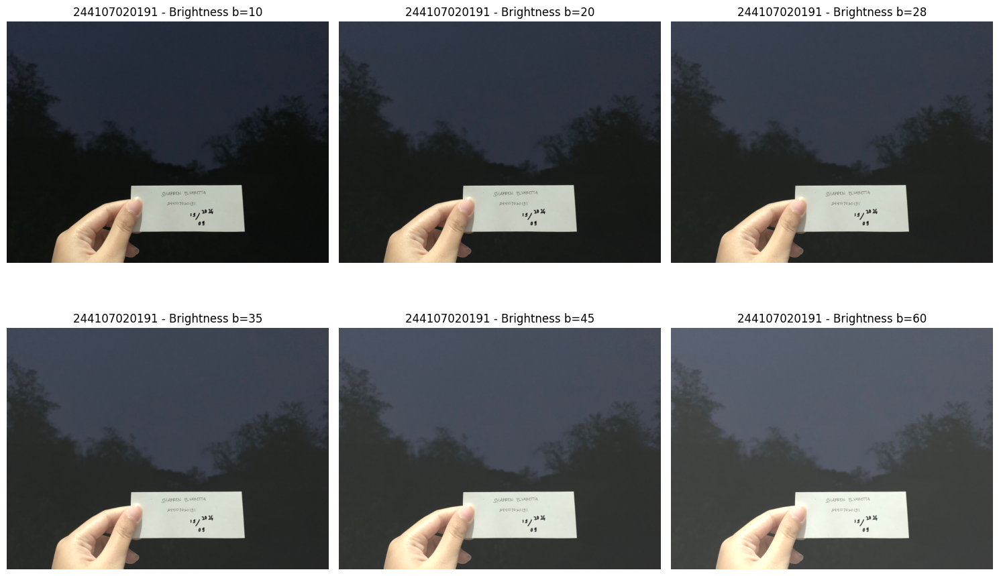

In [86]:
brightness_values = [10, 20, 28, 35, 45, 60]

plt.figure(figsize=(15, 10))

for i, b in enumerate(brightness_values):
    hasil = cv.add(night, np.full(night.shape, b, dtype=np.uint8))

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - Brightness b={b}')
    plt.axis('off')

plt.tight_layout()
plt.show()

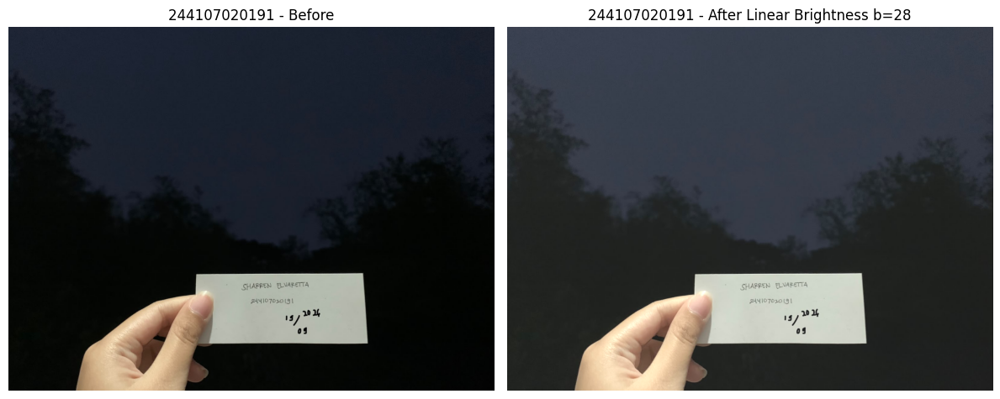

In [87]:
# Parameter terbaik berdasarkan hasil percobaan
b_best = 28

hasil_brightness = cv.add(
    night,
    np.full(night.shape, b_best, dtype=np.uint8)
)

# Before - After
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(night, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_brightness, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - After Linear Brightness b=28')
plt.axis('off')

plt.tight_layout()
plt.show()

### Metode yang dipilih:

Linear Brightness.

### Alasan pemilihan:

Citra NIGHT1 memiliki kondisi pencahayaan yang gelap sehingga beberapa detail sulit terlihat. Linear Brightness dipilih untuk meningkatkan kecerahan seluruh piksel secara langsung.

### Parameter terbaik:

Berdasarkan percobaan beberapa nilai brightness, yaitu 10, 20, 28, 35, 45, dan 60, dipilih b = 28 karena mampu membuat objek dan tulisan pada citra lebih terlihat tanpa menyebabkan bagian yang terang menjadi berlebihan.

### Risiko:

Peningkatan brightness yang terlalu besar dapat menyebabkan bagian citra menjadi terlalu terang (overexposure) dan detail pada area terang berkurang.

### Kesimpulan:

Linear Brightness dengan parameter b = 28 dapat meningkatkan keterlihatan detail pada foto malam. Nilai yang terlalu tinggi dapat membuat citra menjadi terlalu terang, sehingga pemilihan parameter perlu disesuaikan dengan kondisi citra.